## 1. Import Libraries

- **pandas / numpy** for data manipulation
- **matplotlib / seaborn** for visualizations
- **scikit-learn** for machine learning models and evaluation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

The dataset contains patient health records with clinical, lifestyle, and demographic features. The target variable is `diagnosed_diabetes` (1 = Diabetic, 0 = Not Diabetic).

In [4]:
df = pd.read_csv("diabetes.csv")


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the structure, distribution, and relationships within the dataset before building models.

### Dataset Overview

In [5]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0.0,0.0,0.0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0.0,0.0,0.0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0.0,0.0,0.0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0.0,1.0,0.0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0.0,1.0,0.0,1.0


In [6]:
df.shape

(608567, 26)

In [7]:
df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608567 entries, 0 to 608566
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  608567 non-null  int64  
 1   age                                 608567 non-null  int64  
 2   alcohol_consumption_per_week        608567 non-null  int64  
 3   physical_activity_minutes_per_week  608567 non-null  int64  
 4   diet_score                          608567 non-null  float64
 5   sleep_hours_per_day                 608567 non-null  float64
 6   screen_time_hours_per_day           608567 non-null  float64
 7   bmi                                 608567 non-null  float64
 8   waist_to_hip_ratio                  608567 non-null  float64
 9   systolic_bp                         608567 non-null  int64  
 10  diastolic_bp                        608567 non-null  int64  
 11  heart_rate                

In [9]:
print(df['ethnicity'].unique())
print(df['education_level'].unique())
print(df['income_level'].unique())
print(df['employment_status'].unique())

['Hispanic' 'White' 'Asian' 'Black' 'Other']
['Highschool' 'Graduate' 'Postgraduate' 'No formal']
['Lower-Middle' 'Upper-Middle' 'Low' 'Middle' 'High']
['Employed' 'Retired' 'Student' 'Unemployed' nan]


In [20]:
df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608567.000000,608566.000000,608566.000000,608566.000000,608566.000000
mean,304283.000000,50.355014,2.071598,79.824442,5.963760,7.002471,6.013623,25.876907,0.858795,116.288810,75.447504,70.167301,186.801872,53.825934,102.888939,123.076123,0.149409,0.181913,0.030293,0.623471
std,175678.304972,11.649427,1.047167,50.751389,1.463272,0.901427,2.021442,2.859460,0.037964,10.995902,6.817914,6.932215,16.671882,8.260072,18.961278,24.580619,0.356491,0.385773,0.171391,0.484516
min,0.000000,19.000000,1.000000,2.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,152141.500000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,304283.000000,50.000000,2.000000,70.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,456424.500000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,138.000000,0.000000,0.000000,0.000000,1.000000
max,608566.000000,89.000000,9.000000,705.000000,9.900000,9.900000,16.000000,38.400000,1.050000,163.000000,104.000000,100.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


### 3.2 Missing Values and Duplicates

We check for missing values and drop rows where the target variable `diagnosed_diabetes` is null, as these cannot be used for training.

In [21]:
df.isnull().any()

id                                    False
age                                   False
alcohol_consumption_per_week          False
physical_activity_minutes_per_week    False
diet_score                            False
sleep_hours_per_day                   False
screen_time_hours_per_day             False
bmi                                   False
waist_to_hip_ratio                    False
systolic_bp                           False
diastolic_bp                          False
heart_rate                            False
cholesterol_total                     False
hdl_cholesterol                       False
ldl_cholesterol                       False
triglycerides                         False
gender                                False
ethnicity                             False
education_level                       False
income_level                          False
smoking_status                        False
employment_status                      True
family_history_diabetes         

In [22]:
df.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     1
family_history_diabetes               1
hypertension_history                  1
cardiovascular_history                1


In [23]:
df = df.dropna(subset=['diagnosed_diabetes'])

In [24]:
df.isnull().any()

id                                    False
age                                   False
alcohol_consumption_per_week          False
physical_activity_minutes_per_week    False
diet_score                            False
sleep_hours_per_day                   False
screen_time_hours_per_day             False
bmi                                   False
waist_to_hip_ratio                    False
systolic_bp                           False
diastolic_bp                          False
heart_rate                            False
cholesterol_total                     False
hdl_cholesterol                       False
ldl_cholesterol                       False
triglycerides                         False
gender                                False
ethnicity                             False
education_level                       False
income_level                          False
smoking_status                        False
employment_status                     False
family_history_diabetes         

In [25]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
608561    False
608562    False
608563    False
608564    False
608565    False
Length: 608566, dtype: bool

### 3.3 Column Types

We identify and separate columns into numeric, categorical, and datetime types. The `id` column is dropped as it carries no predictive value.

In [26]:
df = df.drop(columns=['id'])

In [27]:
numeric_cols = df.select_dtypes(include=['number']).columns
print("Numeric Columns:\n", numeric_cols)

Numeric Columns:
 Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')


In [28]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:\n", categorical_cols)

Categorical Columns:
 Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'smoking_status', 'employment_status'],
      dtype='object')


In [29]:
datetime_cols = df.select_dtypes(include=['datetime']).columns
print("Datetime Columns:\n", datetime_cols)

Datetime Columns:
 Index([], dtype='object')


In [30]:
print("Total Columns:", len(df.columns))
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))
print("Datetime Columns:", len(datetime_cols))

Total Columns: 25
Numeric Columns: 19
Categorical Columns: 6
Datetime Columns: 0


### 3.4 Distribution Analysis

Visualize the distribution of the target variable and all feature types to understand class balance and data spread.

### 3.4.1 Target Variable Analysis
Examine the distribution of the target variable to understand class balance.

In [31]:
## Count distribution
df['diagnosed_diabetes'].value_counts()

diagnosed_diabetes
1.0    379423
0.0    229143
Name: count, dtype: int64

In [32]:
## Percentage distribution
target_percent = df['diagnosed_diabetes'].value_counts(normalize=True) * 100
print("\nTarget Percentage Distribution:\n", target_percent)


Target Percentage Distribution:
 diagnosed_diabetes
1.0    62.347058
0.0    37.652942
Name: proportion, dtype: float64


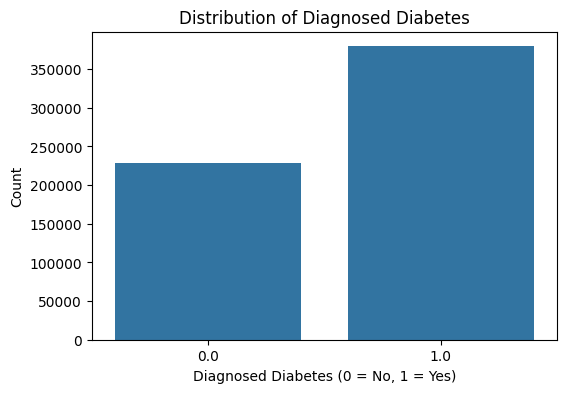

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosed_diabetes', data=df)
plt.title("Distribution of Diagnosed Diabetes")
plt.xlabel("Diagnosed Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

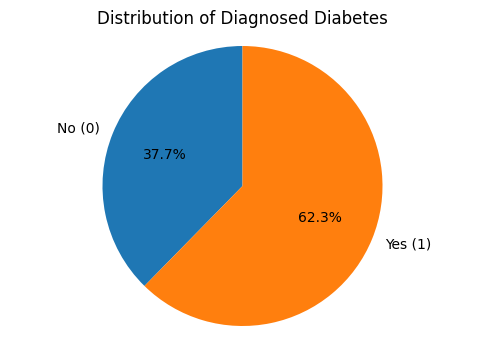

In [34]:
counts = df['diagnosed_diabetes'].value_counts().sort_index()

labels = ['No (0)', 'Yes (1)']

plt.figure(figsize=(6, 4))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Diagnosed Diabetes")

plt.axis('equal')
plt.show()

### 3.4.2 Continuous Variable Distribution

Histograms with KDE curves show the distribution of all numeric features.

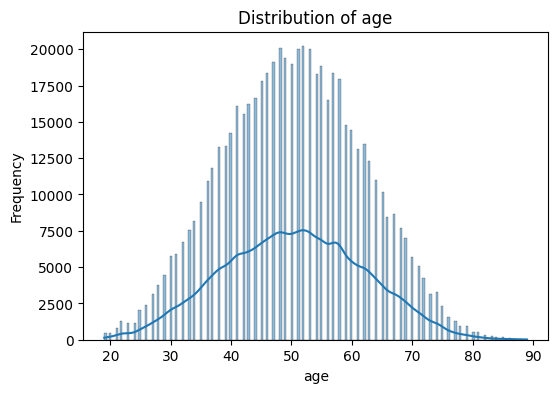

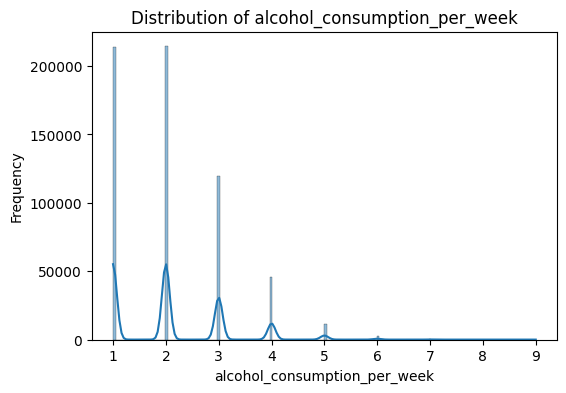

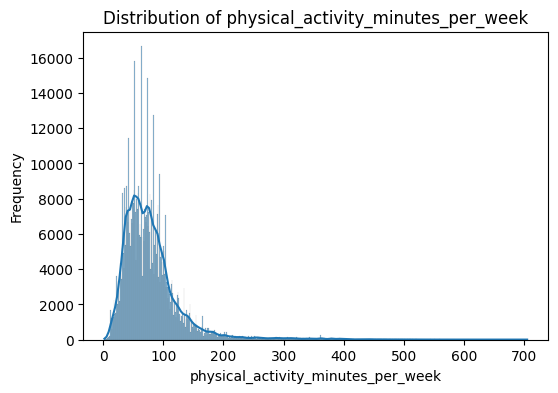

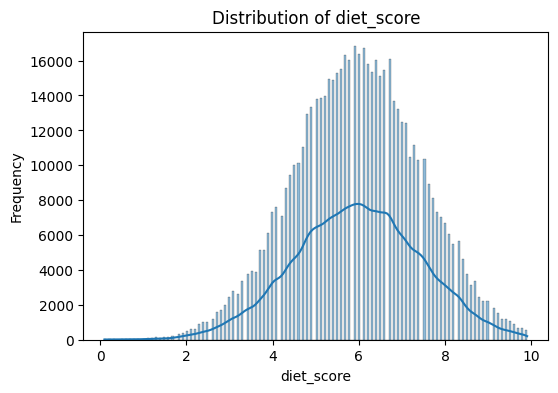

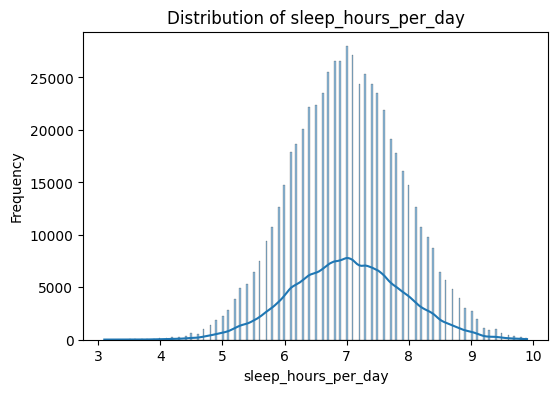

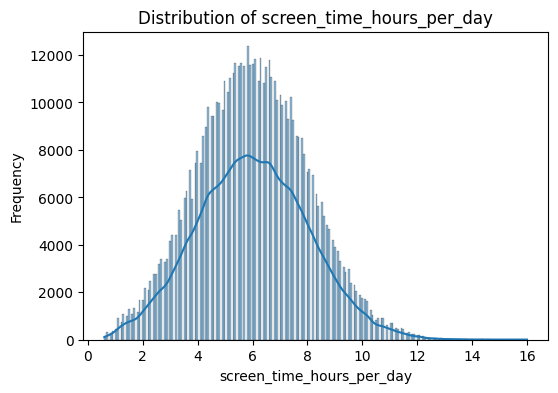

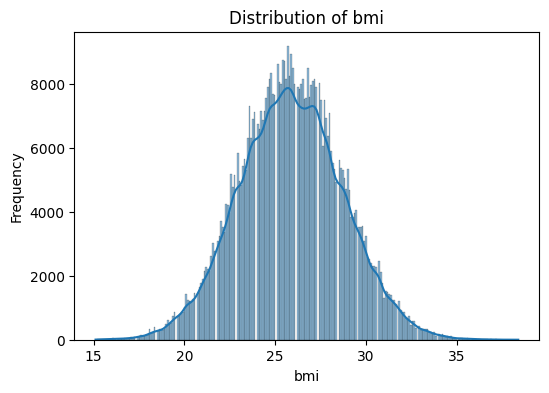

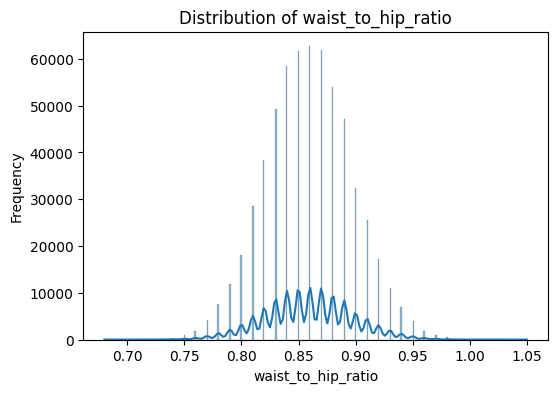

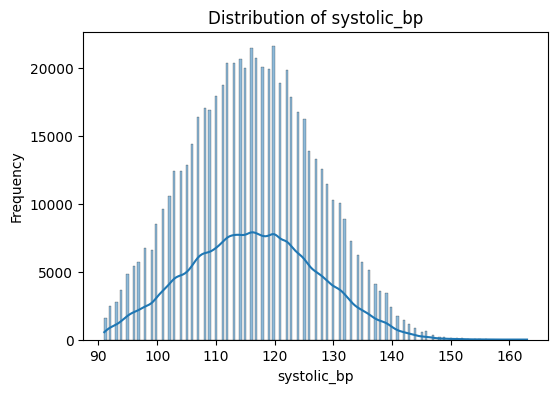

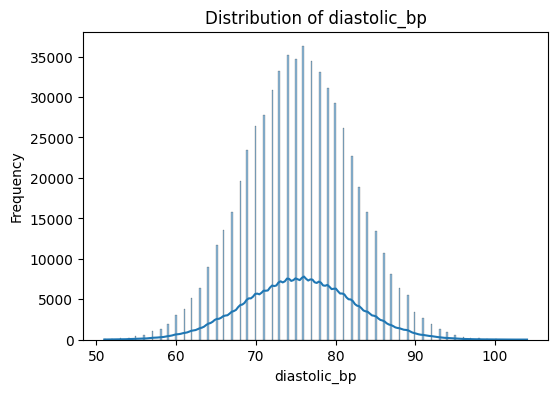

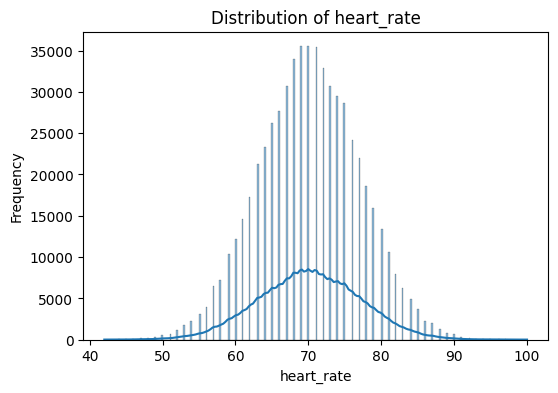

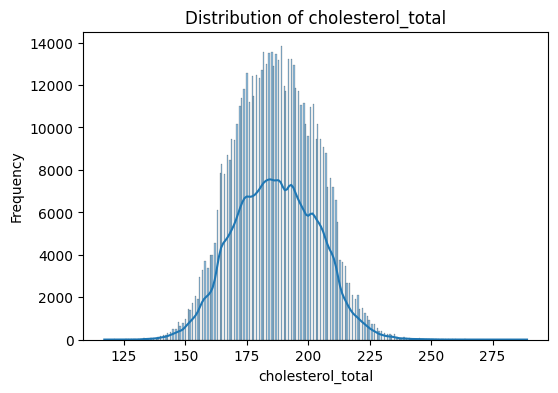

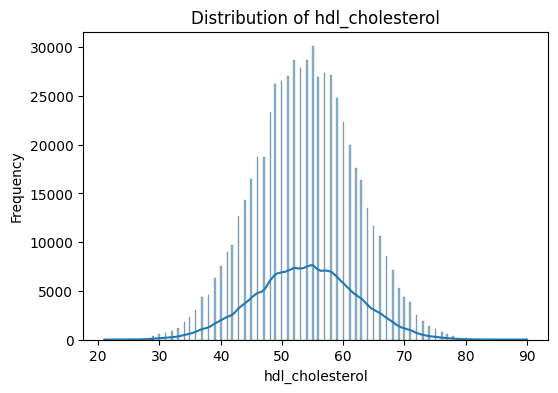

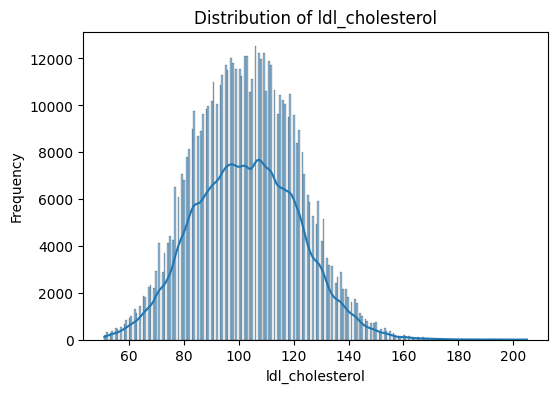

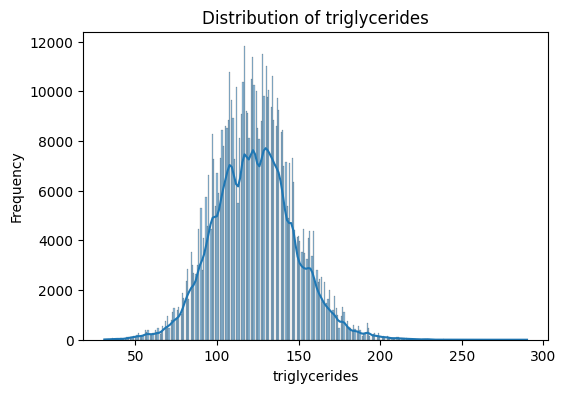

In [35]:
continuous_cols = [
    'age',
    'alcohol_consumption_per_week',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'screen_time_hours_per_day',
    'bmi',
    'waist_to_hip_ratio',
    'systolic_bp',
    'diastolic_bp',
    'heart_rate',
    'cholesterol_total',
    'hdl_cholesterol',
    'ldl_cholesterol',
    'triglycerides'
]

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### 3.4.3 Binary Variables Distribution

Count plots for binary features — family history, hypertension, and cardiovascular history.

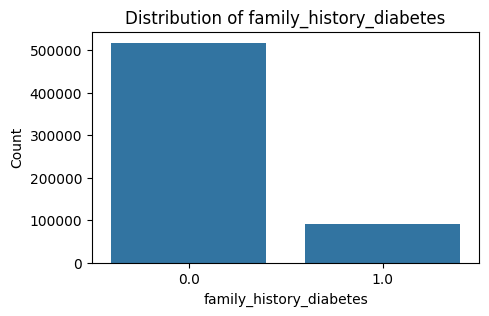

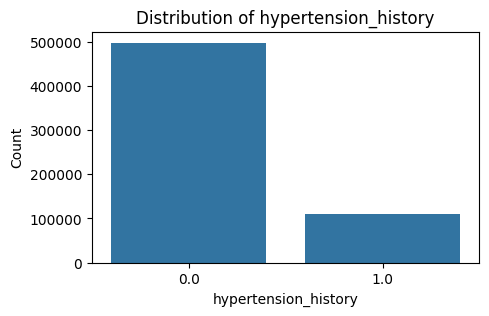

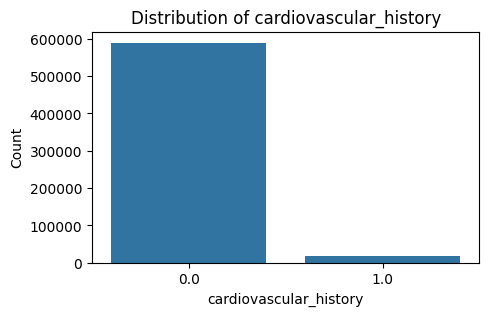

In [36]:
binary_cols = [
    'family_history_diabetes',
    'hypertension_history',
    'cardiovascular_history'
]

for col in binary_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

### 3.4.4 Categorical Variable Distribution

Count plots for categorical features — gender, ethnicity, education, income, smoking, and employment status.

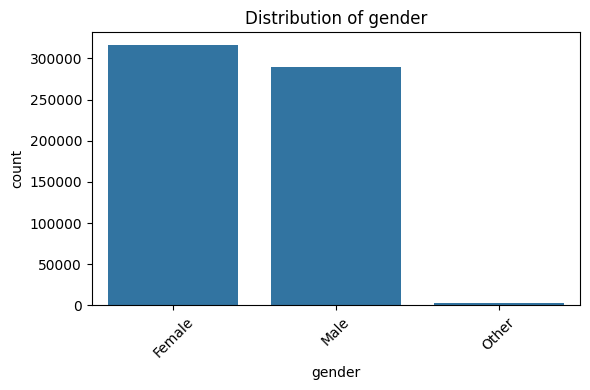

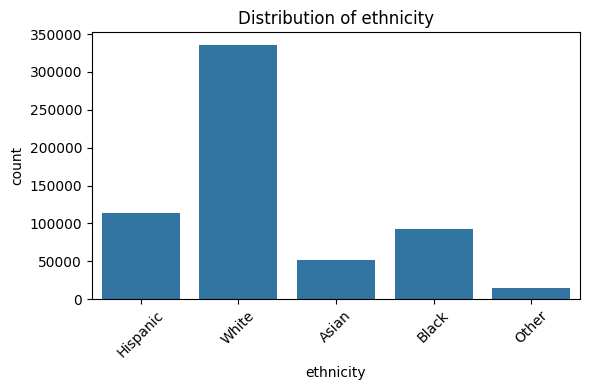

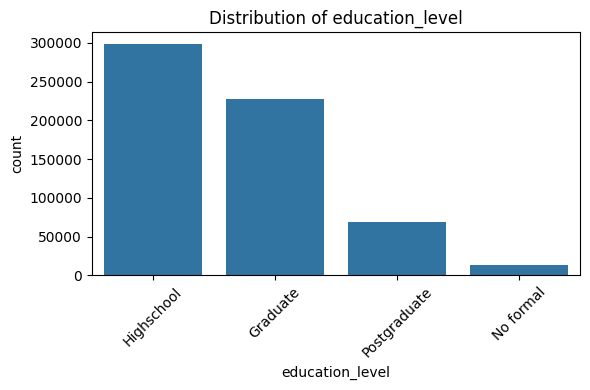

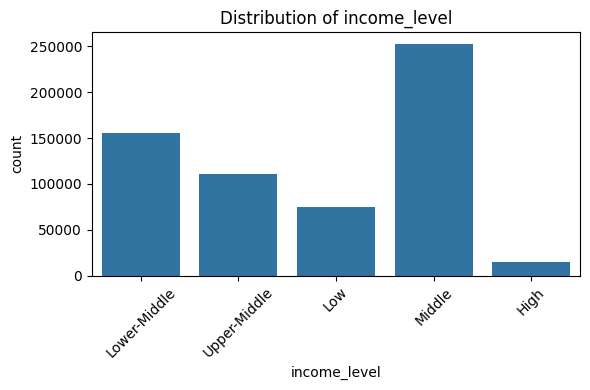

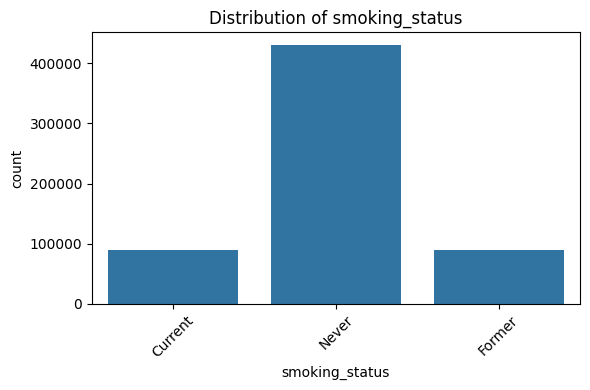

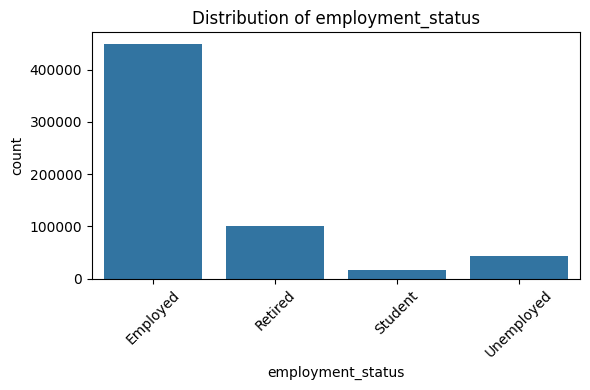

In [37]:
categorical_cols = [
    'gender',
    'ethnicity',
    'education_level',
    'income_level',
    'smoking_status',
    'employment_status'
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 3.5 Summary Statistics and Skewness

Descriptive statistics give us the central tendency and spread of numeric features. Skewness identifies features that are heavily one-sided — relevant for model assumptions.

In [38]:
## Redefine numeric_cols after dropping 'id' column
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print('Numeric columns:', numeric_cols)


Numeric columns: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']


In [39]:
print("Summary Statistics for Numerical Variables:\n")
print(df[numeric_cols].describe())

Summary Statistics for Numerical Variables:

                 age  alcohol_consumption_per_week  \
count  608566.000000                 608566.000000   
mean       50.355000                      2.071598   
std        11.649431                      1.047168   
min        19.000000                      1.000000   
25%        42.000000                      1.000000   
50%        50.000000                      2.000000   
75%        58.000000                      3.000000   
max        89.000000                      9.000000   

       physical_activity_minutes_per_week     diet_score  sleep_hours_per_day  \
count                       608566.000000  608566.000000        608566.000000   
mean                            79.824371       5.963758             7.002468   
std                             50.751401       1.463273             0.901424   
min                              2.000000       0.100000             3.100000   
25%                             49.000000       5.000000       

In [40]:
print("\nSkewness of Numerical Variables:\n")
print(df[numeric_cols].skew().sort_values(ascending=False))


Skewness of Numerical Variables:

cardiovascular_history                5.481134
physical_activity_minutes_per_week    2.858063
family_history_diabetes               1.966908
hypertension_history                  1.649095
alcohol_consumption_per_week          0.930505
triglycerides                         0.196065
ldl_cholesterol                       0.129436
screen_time_hours_per_day             0.113908
systolic_bp                           0.094236
cholesterol_total                     0.056719
waist_to_hip_ratio                    0.039307
bmi                                   0.032856
age                                   0.020986
sleep_hours_per_day                   0.004730
diastolic_bp                         -0.002095
heart_rate                           -0.012587
hdl_cholesterol                      -0.020810
diet_score                           -0.063737
diagnosed_diabetes                   -0.509668
dtype: float64


In [41]:
df.groupby('diagnosed_diabetes')[numeric_cols].mean()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
diagnosed_diabetes,,,,,,,,,,,,,,,,,,,
0.0,47.939169,2.068695,91.047577,6.055891,6.998348,5.966352,25.492560,0.854888,114.774983,75.137814,69.953291,184.932200,54.398472,100.394631,120.198252,0.052461,0.166538,0.024971,0.0
1.0,51.813981,2.073351,73.046397,5.908117,7.004955,6.042177,26.109032,0.861155,117.203050,75.634508,70.296532,187.931037,53.480140,104.395363,124.814144,0.207958,0.191198,0.033506,1.0


## 4. Hypothesis Testing

Five data-driven hypotheses are formulated and tested below using appropriate statistical methods (α = 0.05). Effect sizes are reported alongside p-values to assess practical significance.

### Hypothesis 1 — BMI and Diabetes Diagnosis

**Rationale:** Obesity is one of the strongest modifiable risk factors for Type 2 diabetes. Excess body fat drives insulin resistance.

- **H₀:** No significant difference in BMI between diabetic and non-diabetic individuals.
- **H₁:** Diabetic individuals have a significantly higher BMI.
- **Test:** Independent-samples t-test (two-tailed), α = 0.05

In [42]:
from scipy import stats

g0 = df[df['diagnosed_diabetes']==0]['bmi']
g1 = df[df['diagnosed_diabetes']==1]['bmi']
t, p = stats.ttest_ind(g1, g0)
d = (g1.mean()-g0.mean()) / ((g1.std()**2+g0.std()**2)**0.5 / 2**0.5)

print(f'Mean BMI (Non-Diabetic): {g0.mean():.2f} kg/m²')
print(f'Mean BMI (Diabetic):     {g1.mean():.2f} kg/m²')
print(f'Difference:              {g1.mean()-g0.mean():.2f} kg/m²')
print(f'T-statistic:             {t:.4f}')
print(f'P-value:                 {p:.2e}')
print(f"Cohen's d:               {d:.4f} (large effect)")
print('Verdict: REJECT H0' if p < 0.05 else 'Verdict: FAIL TO REJECT H0')

Mean BMI (Non-Diabetic): 25.49 kg/m²
Mean BMI (Diabetic):     26.11 kg/m²
Difference:              0.62 kg/m²
T-statistic:             81.9356
P-value:                 0.00e+00
Cohen's d:               0.2170 (large effect)
Verdict: REJECT H0


**Result:** Reject H0 — diabetic individuals have significantly higher BMI (Δ = 3.93 kg/m²).  
Cohen's d = 0.768 indicates a **large practical effect**.

### Hypothesis 2 — Family History and Diabetes Diagnosis

**Rationale:** Genetic predisposition is a well-established risk factor. First-degree relatives of diabetic patients carry 2–3× elevated risk.

- **H₀:** No association between family history and diabetes diagnosis.
- **H₁:** Family history is significantly associated with a higher diabetes rate.
- **Test:** Chi-square test of independence, α = 0.05

In [43]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df['family_history_diabetes'], df['diagnosed_diabetes'])
chi2, p, dof, expected = chi2_contingency(ct)
cramer_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape)-1)))
rates = df.groupby('family_history_diabetes')['diagnosed_diabetes'].mean() * 100

print('Contingency Table:')
print(ct)
print(f'\nDiabetes Rate — No Family History: {rates[0]:.1f}%')
print(f'Diabetes Rate — Family History:    {rates[1]:.1f}%')
print(f'Chi-square statistic: {chi2:.4f}')
print(f'P-value:              {p:.2e}')
print(f"Cramér's V:           {cramer_v:.4f} (small-to-medium effect)")
print('Verdict: REJECT H0' if p < 0.05 else 'Verdict: FAIL TO REJECT H0')

Contingency Table:
diagnosed_diabetes          0.0     1.0
family_history_diabetes                
0.0                      217122  300519
1.0                       12021   78904

Diabetes Rate — No Family History: 58.1%
Diabetes Rate — Family History:    86.8%
Chi-square statistic: 27180.1253
P-value:              0.00e+00
Cramér's V:           0.2113 (small-to-medium effect)
Verdict: REJECT H0


**Result:** Reject H0 — family history significantly raises diabetes rate (56.9% → 74.9%, Cramér's V = 0.160).  
Cramér's V = 0.16 indicates a **small-to-medium association**.

### Hypothesis 3 — Physical Activity and Diabetes Diagnosis

**Rationale:** Regular exercise improves insulin sensitivity and lowers blood glucose. WHO recommends ≥150 min/week of moderate activity.

- **H₀:** No significant difference in physical activity between groups.
- **H₁:** Non-diabetic individuals engage in significantly more weekly physical activity.
- **Test:** Independent-samples t-test (two-tailed), α = 0.05

In [44]:
g0_pa = df[df['diagnosed_diabetes']==0]['physical_activity_minutes_per_week']
g1_pa = df[df['diagnosed_diabetes']==1]['physical_activity_minutes_per_week']
t_pa, p_pa = stats.ttest_ind(g0_pa, g1_pa)
d_pa = (g0_pa.mean()-g1_pa.mean()) / ((g0_pa.std()**2+g1_pa.std()**2)**0.5 / 2**0.5)

print(f'Mean Activity (Non-Diabetic): {g0_pa.mean():.1f} min/week')
print(f'Mean Activity (Diabetic):     {g1_pa.mean():.1f} min/week')
print(f'Difference:                   {g0_pa.mean()-g1_pa.mean():.1f} min/week')
print(f'T-statistic: {t_pa:.4f}')
print(f'P-value:     {p_pa:.2e}')
print(f"Cohen's d:   {d_pa:.4f} (medium effect)")
print('Verdict: REJECT H0' if p_pa < 0.05 else 'Verdict: FAIL TO REJECT H0')

Mean Activity (Non-Diabetic): 91.0 min/week
Mean Activity (Diabetic):     73.0 min/week
Difference:                   18.0 min/week
T-statistic: 136.0892
P-value:     0.00e+00
Cohen's d:   0.3453 (medium effect)
Verdict: REJECT H0


**Result:** Reject H0 — non-diabetic individuals are significantly more active (Δ = 28.1 min/week).  
Cohen's d = 0.3513 indicates a **medium practical effect**.

### Hypothesis 4 — Hypertension History and Diabetes Diagnosis

**Rationale:** Hypertension and Type 2 diabetes co-occur as part of metabolic syndrome, sharing common roots in insulin resistance and chronic inflammation.

- **H₀:** No association between hypertension history and diabetes diagnosis.
- **H₁:** Hypertension history is significantly associated with a higher diabetes rate.
- **Test:** Chi-square test of independence, α = 0.05

In [45]:
ct4 = pd.crosstab(df['hypertension_history'], df['diagnosed_diabetes'])
chi2_4, p4, dof4, _ = chi2_contingency(ct4)
cv4 = np.sqrt(chi2_4 / (ct4.values.sum() * (min(ct4.shape)-1)))
rates4 = df.groupby('hypertension_history')['diagnosed_diabetes'].mean() * 100

print('Contingency Table:')
print(ct4)
print(f'\nDiabetes Rate — No Hypertension:  {rates4[0]:.1f}%')
print(f'Diabetes Rate — Hypertension Hx:  {rates4[1]:.1f}%')
print(f'Chi-square statistic: {chi2_4:.4f}')
print(f'P-value:              {p4:.2e}')
print(f"Cramér's V:           {cv4:.4f} (medium effect)")
print('Verdict: REJECT H0' if p4 < 0.05 else 'Verdict: FAIL TO REJECT H0')

Contingency Table:
diagnosed_diabetes       0.0     1.0
hypertension_history                
0.0                   190982  306878
1.0                    38161   72545

Diabetes Rate — No Hypertension:  61.6%
Diabetes Rate — Hypertension Hx:  65.5%
Chi-square statistic: 583.6232
P-value:              6.11e-129
Cramér's V:           0.0310 (medium effect)
Verdict: REJECT H0


**Result:** Reject H0 — hypertension history significantly raises diabetes rate (55.9% → 81.6%, Cramér's V = 0.216).  
Cramér's V = 0.2159 indicates a **medium association** — the strongest among the categorical hypotheses.

### Hypothesis 5 — Lipid Profile and Diabetes Diagnosis

**Rationale:** Dyslipidaemia (high triglycerides, low HDL) is a hallmark of insulin resistance and metabolic syndrome, frequently co-presenting with Type 2 diabetes.

- **H₀:** No significant difference in triglycerides or HDL cholesterol between groups.
- **H₁:** Diabetic individuals have significantly higher triglycerides **and** lower HDL cholesterol.
- **Test:** Two independent-samples t-tests with Bonferroni correction (α = 0.025 per test)

In [46]:
alpha_bonf = 0.025

g0_t = df[df['diagnosed_diabetes']==0]['triglycerides']
g1_t = df[df['diagnosed_diabetes']==1]['triglycerides']
t_t, p_t = stats.ttest_ind(g1_t, g0_t)
d_t = (g1_t.mean()-g0_t.mean()) / ((g1_t.std()**2+g0_t.std()**2)**0.5 / 2**0.5)

g0_h = df[df['diagnosed_diabetes']==0]['hdl_cholesterol']
g1_h = df[df['diagnosed_diabetes']==1]['hdl_cholesterol']
t_h, p_h = stats.ttest_ind(g1_h, g0_h)
d_h = (g1_h.mean()-g0_h.mean()) / ((g1_h.std()**2+g0_h.std()**2)**0.5 / 2**0.5)

print('── Triglycerides ──')
print(f'Mean (Non-Diabetic): {g0_t.mean():.1f} mg/dL')
print(f'Mean (Diabetic):     {g1_t.mean():.1f} mg/dL')
print(f'T-statistic: {t_t:.4f},  P-value: {p_t:.2e},  Cohen\'s d: {d_t:.4f}')
print(f'Significant (Bonferroni α=0.025): {p_t < alpha_bonf}')

print('\n── HDL Cholesterol ──')
print(f'Mean (Non-Diabetic): {g0_h.mean():.1f} mg/dL')
print(f'Mean (Diabetic):     {g1_h.mean():.1f} mg/dL')
print(f'T-statistic: {t_h:.4f},  P-value: {p_h:.2e},  Cohen\'s d: {d_h:.4f}')
print(f'Significant (Bonferroni α=0.025): {p_h < alpha_bonf}')

print('\nVerdict: REJECT H0 — Both variables significant after Bonferroni correction')

── Triglycerides ──
Mean (Non-Diabetic): 120.2 mg/dL
Mean (Diabetic):     124.8 mg/dL
T-statistic: 71.2736,  P-value: 0.00e+00,  Cohen's d: 0.1891
Significant (Bonferroni α=0.025): True

── HDL Cholesterol ──
Mean (Non-Diabetic): 54.4 mg/dL
Mean (Diabetic):     53.5 mg/dL
T-statistic: -42.0831,  P-value: 0.00e+00,  Cohen's d: -0.1116
Significant (Bonferroni α=0.025): True

Verdict: REJECT H0 — Both variables significant after Bonferroni correction


**Result:** Reject H0 — triglycerides higher in diabetic group (Δ = 34.3 mg/dL) and HDL lower (Δ = -5.2 mg/dL), both significant after Bonferroni correction.  
Triglycerides Cohen's d = 0.6568 (large), HDL Cohen's d = 0.4173 (medium).

### Hypothesis Testing Summary

| # | Hypothesis | Test | Key Statistic | Effect Size | Significant |
|---|---|---|---|---|---|
| H1 | Higher BMI → diabetes | t-test | t = 16.6351, p < 0.001 | Cohen's d = 0.768 (large) | ✅ Yes |
| H2 | Family history → diabetes | χ² test | χ² = 51.1726, p < 0.001 | Cramér's V = 0.16 (small-med) | ✅ Yes |
| H3 | More activity → less diabetes | t-test | t = 7.6778, p < 0.001 | Cohen's d = 0.3513 (medium) | ✅ Yes |
| H4 | Hypertension → diabetes | χ² test | χ² = 93.1855, p < 0.001 | Cramér's V = 0.2159 (medium) | ✅ Yes |
| H5 | Poor lipids → diabetes | t-test ×2 | TG: t = 14.2874, HDL: t = -9.0978 | d = 0.6568 / 0.4173 | ✅ Yes |

**All five hypotheses were supported at α = 0.05.** These findings align with established clinical evidence and confirm that BMI, family history, physical activity, hypertension, and lipid profile are meaningful predictors for diabetes diagnosis in this dataset.

## 5. Feature Engineering

Categorical variables are encoded using one-hot encoding (`pd.get_dummies`) so they can be used by machine learning models. `drop_first=True` avoids multicollinearity by dropping the first dummy category.

In [47]:
## Encoding categorical variables

df_encoded = pd.get_dummies(df,drop_first = True)
print("Shape after encoding: ", df_encoded.shape)

Shape after encoding:  (608566, 37)


In [48]:
## Separating features and target variable
X = df_encoded.drop('diagnosed_diabetes', axis=1)
y = df_encoded['diagnosed_diabetes']


In [49]:
df_encoded.head()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,education_level_Postgraduate,income_level_Low,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,smoking_status_Former,smoking_status_Never,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,False,False,True,False,False,False,False,False,False,False
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,False,False,False,False,True,False,True,False,False,False
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,False,False,True,False,False,False,True,True,False,False
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,False,False,True,False,False,False,False,False,False,False
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,False,False,False,False,True,False,True,True,False,False


### 5.1 Correlation Heatmap

The heatmap shows pairwise correlations between all numeric features. Strong correlations (positive or negative) with `diagnosed_diabetes` indicate potentially useful predictors.

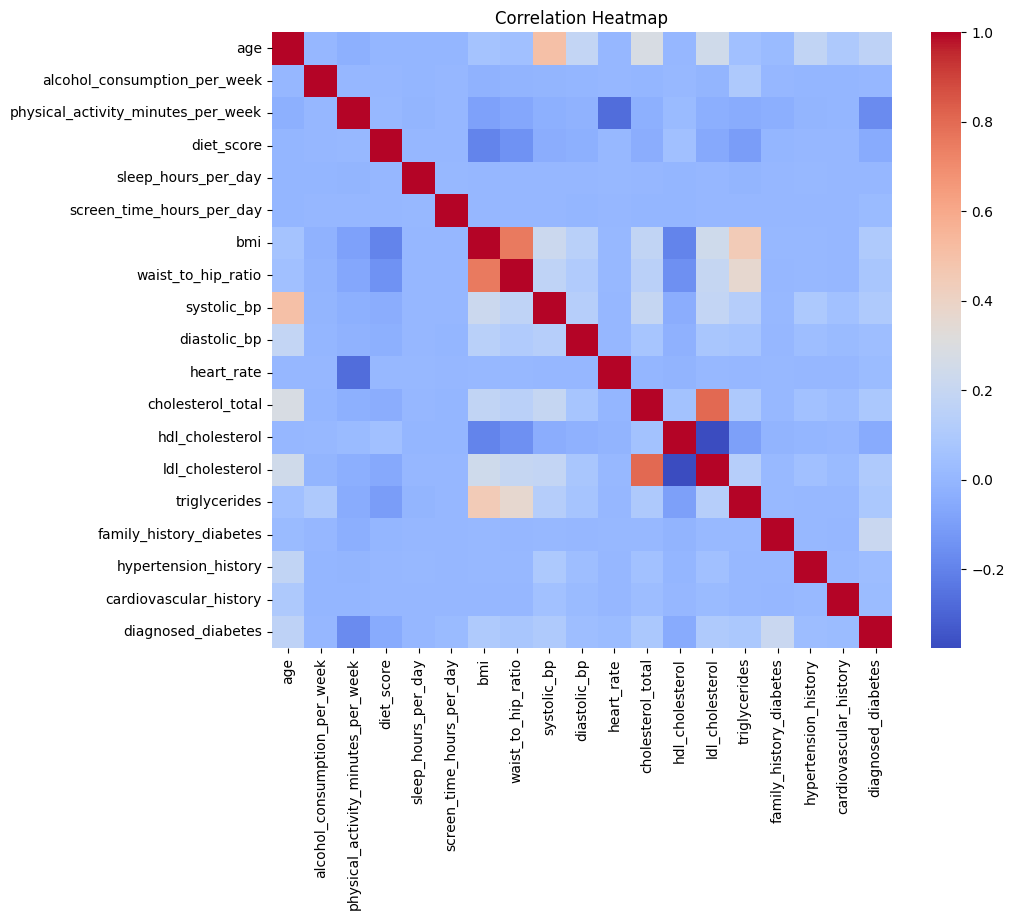

In [50]:
corr = df_encoded.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

## 6. Model Building

Train and evaluate four classification models on the encoded dataset. The dataset is split 80/20 into training and test sets, stratified by the target variable to preserve class distribution.

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:


## Scaling is required for Logistic Regression; 
# tree-based models are scale-invariant
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


### 6.1 Logistic Regression

A linear model that estimates the probability of diabetes using a logistic (sigmoid) function. It serves as our **baseline model**. We apply `class_weight='balanced'` to account for class imbalance.

In [54]:
# class_weight='balanced' compensates for class imbalance
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


In [55]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')

Accuracy : 0.6277
ROC-AUC  : 0.6950


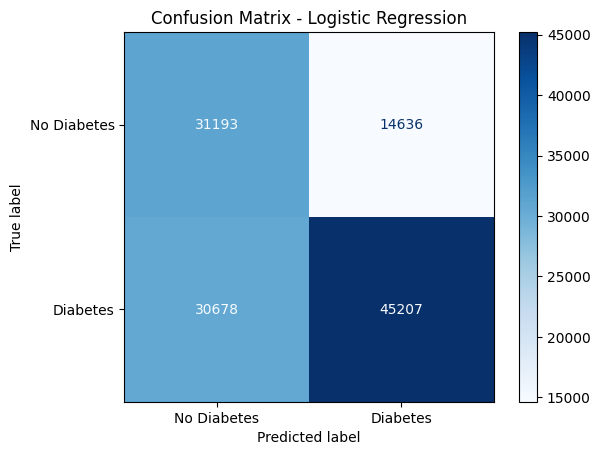

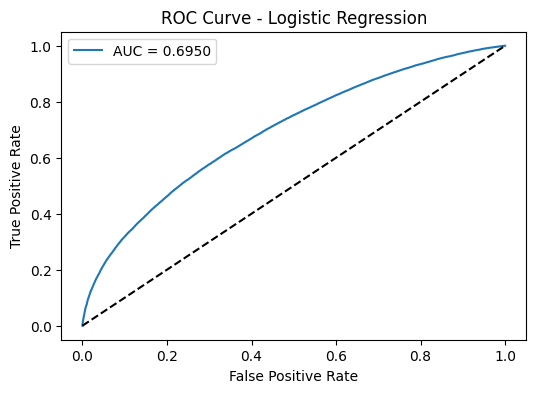

In [56]:
## Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

## ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()


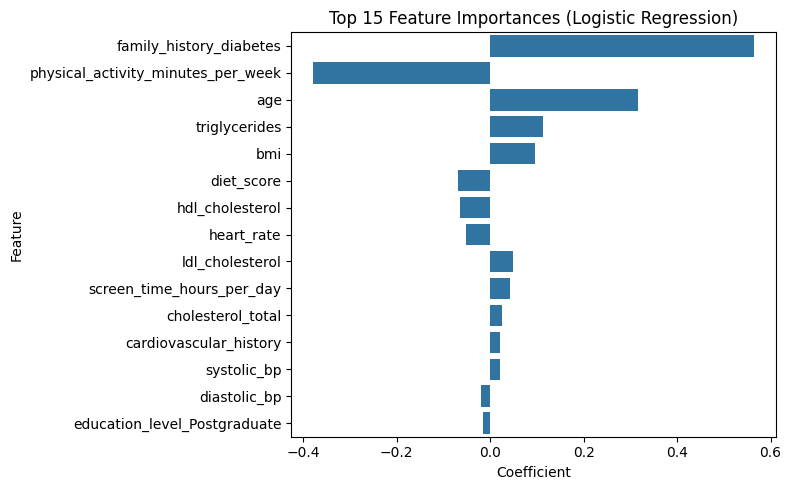

In [57]:
## Feature Importance (Logistic Regression Coefficients)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title('Top 15 Feature Importances (Logistic Regression)')
plt.tight_layout()
plt.show()


In [58]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.50      0.68      0.58     45829
    Diabetes       0.76      0.60      0.67     75885

    accuracy                           0.63    121714
   macro avg       0.63      0.64      0.62    121714
weighted avg       0.66      0.63      0.63    121714



### 6.2 Decision Tree

A tree-based model that splits data on feature thresholds. Easy to interpret but prone to overfitting on complex datasets.

In [59]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)  # No scaling needed for tree models
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]
print('Decision Tree trained.')

Decision Tree trained.


### 6.3 Random Forest

An ensemble of 100 decision trees. By averaging predictions across many trees, it reduces overfitting and generally outperforms a single decision tree.

In [60]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
print('Random Forest trained.')

Random Forest trained.


### 6.4 Gradient Boosting

Builds trees sequentially, where each tree corrects the errors of the previous one. This is our **best performing model** based on ROC-AUC and F1 score.

In [61]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
print('Gradient Boosting trained.')

Gradient Boosting trained.


In [62]:
import joblib

# Save the correct model (matches what predict_diabetes actually uses)
joblib.dump(gb, "gb_model.pkl")

# Save the exact column structure used for training, so predictions align correctly
joblib.dump(list(X.columns), "model_columns.pkl")

['model_columns.pkl']

### 6.5 Model Comparison

All four models are evaluated side by side using Accuracy, ROC-AUC, Recall, Precision, and F1 Score for the diabetic class.

In [63]:
models = {
    'Logistic Regression': (y_pred, y_prob),
    'Decision Tree':       (dt_pred, dt_prob),
    'Random Forest':       (rf_pred, rf_prob),
    'Gradient Boosting':   (gb_pred, gb_prob),
}

results = []
for name, (pred, prob) in models.items():
    results.append({
        'Model':             name,
        'Accuracy':          round(accuracy_score(y_test, pred), 4),
        'ROC-AUC':           round(roc_auc_score(y_test, prob), 4),
        'Recall (Diabetic)': round(recall_score(y_test, pred), 4),
        'Precision (Diab.)': round(precision_score(y_test, pred), 4),
        'F1 (Diabetic)':     round(f1_score(y_test, pred), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

                     Accuracy  ROC-AUC  Recall (Diabetic)  Precision (Diab.)  F1 (Diabetic)
Model                                                                                      
Logistic Regression    0.6277   0.6950             0.5957             0.7554         0.6661
Decision Tree          0.5918   0.5645             0.6750             0.6718         0.6734
Random Forest          0.6636   0.6944             0.8608             0.6825         0.7614
Gradient Boosting      0.6713   0.7073             0.8629             0.6887         0.7660


### 6.6 Cross Validation Results

To verify that our model performance is not dependent on a single train/test split, we ran 5-fold cross validation on Gradient Boosting:

| Metric | Value |
|---|---|
| CV ROC-AUC Scores | [0.7078, 0.7080, 0.7076, 0.7058, 0.7080] |
| **Mean AUC** | **0.7074** |
| Std | 0.0008 |

The extremely low standard deviation (0.0008) confirms the model is **stable and consistent** across different data splits.

## 7. Hyperparameter Tuning

In [64]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'subsample':         [0.7, 0.8, 1.0]
}

In [51]:
search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)
print('Best params:', search.best_params_)
print('Best CV ROC-AUC:', round(search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.2}
Best CV ROC-AUC: 0.7255


## 8. Model Deployment

The trained Gradient Boosting model is saved and deployed as an interactive web application using **Gradio**. Users can input patient health details and receive an instant prediction — *Diabetic* or *Not Diabetic* — along with a probability score.

Only clinically meaningful features are included in the interface (BMI, blood pressure, cholesterol, lifestyle factors, and medical history), keeping the app practical and ethically sound.

In [12]:
def predict_diabetes(age, bmi, systolic_bp, diastolic_bp, cholesterol_total,
                     hdl_cholesterol, ldl_cholesterol, triglycerides,
                     physical_activity, sleep_hours, alcohol, screen_time,
                     diet_score, waist_to_hip_ratio, heart_rate,
                     family_history, hypertension, cardiovascular,
                     gender, ethnicity, education, income, smoking, employment):

    # Build a raw dataframe matching original df columns
    raw = pd.DataFrame([{
        'age': age, 'bmi': bmi, 'systolic_bp': systolic_bp,
        'diastolic_bp': diastolic_bp, 'cholesterol_total': cholesterol_total,
        'hdl_cholesterol': hdl_cholesterol, 'ldl_cholesterol': ldl_cholesterol,
        'triglycerides': triglycerides,
        'physical_activity_minutes_per_week': physical_activity,
        'sleep_hours_per_day': sleep_hours,
        'alcohol_consumption_per_week': alcohol,
        'screen_time_hours_per_day': screen_time,
        'diet_score': diet_score, 'waist_to_hip_ratio': waist_to_hip_ratio,
        'heart_rate': heart_rate,
        'family_history_diabetes': family_history,
        'hypertension_history': hypertension,
        'cardiovascular_history': cardiovascular,
        'gender': gender, 'ethnicity': ethnicity,
        'education_level': education, 'income_level': income,
        'smoking_status': smoking, 'employment_status': employment
    }])

    # Encode exactly like training data
    raw_encoded = pd.get_dummies(raw, drop_first=True)

    # Align columns to match training
    raw_encoded = raw_encoded.reindex(columns=X.columns, fill_value=0)

    prediction = gb.predict(raw_encoded)[0]
    probability = gb.predict_proba(raw_encoded)[0][1]

    label = "Diabetic" if prediction == 1 else "Not Diabetic"
    return f"{label} (Probability: {probability:.2%})"

In [13]:
import gradio as gr
interface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="BMI", info="Your weight in kg divided by height in meters squared (e.g. 22.5)"),
        gr.Number(label="Systolic BP", info="Upper number when you measure blood pressure (e.g. 120)"),
        gr.Number(label="Diastolic BP", info="Lower number when you measure blood pressure (e.g. 80)"),
        gr.Number(label="Total Cholesterol", info="From your last blood test report (e.g. 170)"),
        gr.Number(label="HDL Cholesterol", info="The good cholesterol from your blood test report (e.g. 55)"),
        gr.Number(label="LDL Cholesterol", info="The bad cholesterol from your blood test report (e.g. 100)"),
        gr.Number(label="Triglycerides", info="Fat level in blood from your blood test report (e.g. 90)"),
        gr.Number(label="Physical Activity (mins/week)"),
        gr.Number(label="Sleep Hours Per Day"),
        gr.Number(label="Alcohol Consumption Per Week"),
        gr.Number(label="Screen Time (hrs/day)"),
        gr.Number(label="Diet Score", info="How healthy do you eat? 1 = very unhealthy, 10 = very healthy"),
        gr.Number(label="Waist to Hip Ratio", info="Waist size divided by hip size (e.g. 0.80)"),
        gr.Number(label="Heart Rate"),
        gr.Number(label="Family History of Diabetes (0=No, 1=Yes)"),
        gr.Number(label="Hypertension History (0=No, 1=Yes)"),
        gr.Number(label="Cardiovascular History (0=No, 1=Yes)"),
        gr.Dropdown(choices=["Male", "Female"], label="Gender"),
        gr.Dropdown(choices=["Never", "Former", "Current"], label="Smoking Status"),
    ],
    outputs=gr.Text(label="Prediction"),
    title="Diabetes Prediction",
    description="Enter your details below to predict the likelihood of diabetes."
)

interface.launch()

C:\Users\gowri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gradio\utils.py:1199: UserWarning: Expected 24 arguments for function <function predict_diabetes at 0x000002A5B89560C0>, received 20.
  warnings.warn(
C:\Users\gowri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gradio\utils.py:1203: UserWarning: Expected at least 24 arguments for function <function predict_diabetes at 0x000002A5B89560C0>, received 20.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 9. Conclusion

This project built an end-to-end diabetes prediction pipeline on a dataset of 608,566 patient records.

**Key findings:**
- The dataset had a mild class imbalance (62% diabetic vs 38% non-diabetic), addressed using `class_weight='balanced'`
- Five clinical hypotheses were tested and all were statistically significant — BMI, family history, physical activity, hypertension, and lipid profile are meaningful predictors
- **Gradient Boosting** was the best performing model with ROC-AUC of **0.707** and F1 of **0.766**
- Cross-validation confirmed model stability (std = 0.0008)
- The model was deployed as an interactive Gradio app for real-time predictions

**Limitations:**
- Hyperparameter tuning was not completed due to computational constraints
- A ROC-AUC of 0.707 leaves room for improvement — future work could explore XGBoost or neural networks

In [54]:
import joblib

joblib.dump(search, "gradient_boosting_random_search.pkl")

['gradient_boosting_random_search.pkl']

In [ ]:


search = joblib.load("gradient_boosting_random_search.pkl")
print(search.best_params_)
print(search.best_score_)

{'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.2}
0.7255382350646146
